In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import itertools
from sklearn.linear_model import ElasticNet

In [15]:
df_raw = pd.read_csv('Data\merged_df_v2.csv')

In [121]:
df = pd.read_csv('Data/yearly_average_dataset.csv')
columns_to_replace = ['modelled_storage_million_m3', 'Depth (m)', 'Area (km²)']
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)

### Modelling

In [19]:
def process_dataframe(df, target_column, test_size=0.1, random_state=42):
    # List of all possible CH4 columns
    carbon_columns = ['CO2_diffusive__mgCO2_m_2_h_1_',
                   'CH4_diffusive__mgCH4_m_2_h_1_', 
                   'CH4_Bubbling__mgCH4_m_2_h_1_']

    # Drop the columns that are not the target column
    filtered_df = df.drop(columns=[col for col in carbon_columns if col != target_column])
    filtered_df = filtered_df.dropna()
    
    log_transform_columns = ['Volume_million_m3', 'Reservoir_area__km2_','CH4_Bubbling__mgCH4_m_2_h_1_']
    
    # Apply log transformation to specified columns
    for column in log_transform_columns:
        if column in filtered_df.columns:
            filtered_df[f'log_{column}'] = np.log10(filtered_df[column]) 
            filtered_df.drop(columns=[column], inplace=True)

    # Update the target column name if it was log-transformed
    if target_column in log_transform_columns:
        target_column = f'log_{target_column}'
    
    X = filtered_df.drop(columns=[target_column])
    y = filtered_df[target_column]
    
    # 划分数据集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # 数据归一化
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [21]:
df_co2 = df_raw[['CO2_diffusive__mgCO2_m_2_h_1_', 'CH4_diffusive__mgCH4_m_2_h_1_','CH4_Bubbling__mgCH4_m_2_h_1_', 'Temperature____', 'Precipitation_kg_m_2_month', 'VPD_Pa', 'rsds_MJ_m2_d', 'Reservoir_area__km2_']]
CO2_X_train_scaled, CO2_X_test_scaled, CO2_y_train, CO2_y_test, CO2_scaler = process_dataframe(df_co2, 'CO2_diffusive__mgCO2_m_2_h_1_')
df_ch4 = df_raw[['CO2_diffusive__mgCO2_m_2_h_1_', 'CH4_diffusive__mgCH4_m_2_h_1_', 'CH4_Bubbling__mgCH4_m_2_h_1_', 'Wind_speed__m_s_1_', 'Age', 'Precipitation_kg_m_2_month', 'VPD_Pa', 'NPP_g_C_m_2_yr', 'Volume_million_m3']]
CH4_X_train_scaled, CH4_X_test_scaled, CH4_y_train, CH4_y_test, CH4_scaler = process_dataframe(df_ch4, 'CH4_diffusive__mgCH4_m_2_h_1_')
df_ebu_ch4 = df_raw[['CO2_diffusive__mgCO2_m_2_h_1_', 'CH4_diffusive__mgCH4_m_2_h_1_', 'CH4_Bubbling__mgCH4_m_2_h_1_', 'Age','VPD_Pa', 'HURS_%', 'rsds_MJ_m2_d']]
ebu_CH4_X_train_scaled, ebu_CH4_X_test_scaled, ebu_CH4_y_train, ebu_CH4_y_test,ebu_CH4_scaler = process_dataframe(df_ebu_ch4, 'CH4_Bubbling__mgCH4_m_2_h_1_')

In [69]:
def elastic_grid_search(X_train_scaled, X_test_scaled,y_train, y_test, carbon_columns,params_number):
    param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1,0.2, 0.3,0.4, 0.5,0.6, 0.7,0.8, 0.9, 1.0]}
    elastic_net = ElasticNet()
    grid_search = GridSearchCV(estimator=elastic_net, param_grid=param_grid, cv=5, scoring='r2')
    grid_search.fit(X_train_scaled, y_train)

    # Best parameters
    print("Best alpha:", grid_search.best_params_['alpha'])
    print("Best l1_ratio:", grid_search.best_params_['l1_ratio'])

    # Fit the model with the best parameters
    best_elastic_net= grid_search.best_estimator_
    best_elastic_net.fit(X_train_scaled, y_train)

    # Predict on the test set
    y_pred = best_elastic_net.predict(X_test_scaled)
    
    y_train_pred = best_elastic_net.predict(X_train_scaled)
    
    
    print("Training set")
    #print(f"RMSE: {train_rmse}")
    #print(f"R^2: {r2_score(10**y_train, 10**y_train_pred)}")
    print(f"R^2: {r2_score(y_train, y_train_pred)}")
    print("Testing set")
    #print(f"RMSE: {rmse}")
    #print(f"R^2: {r2_score(10**y_test, 10**y_pred)}")
    print(f"R^2: {r2_score(y_test, y_pred)}")
    print(carbon_columns)
    # Get the coefficients of the trained ElasticNet model
    coefficients= best_elastic_net.coef_
    # Display the coefficients
    print("Coefficients of the ElasticNet model:", coefficients)
    print("Intercept of the ElasticNet model:",best_elastic_net.intercept_)
    #print('Stand error of residuals:', s)
    return best_elastic_net

In [71]:
df_gres['annual_runoff_mm_yr'] = df_gres['discharge__m3_s_1_']*60*60*24*365*df_gres['Catchment area (km2)']
df_gres['Water Residence Time (WRT, yrs)']=((df_gres['Mean_depth__m_']*df_gres['Reservoir_area__km2_'])/(df_gres['Catchment area (km2)']*df_gres['annual_runoff_mm_yr']))*1000
df_gres['Age'] = df_gres['Year of samping']-df_gres['Impoundment year']
df_gres.loc[df_gres['Age']<=0,'Age']=0.5
deg_target_column = 'Difference CH4 concentration reservoir intake-outlet (mgC L-1)'
deg_filtered_df = df_gres.drop(columns=['Reservoir name', 'GRanD ID', 'Impoundment year', 'Longitude (DD)',
       'Latitude (DD)', 'Climate zone ','Littoral area (%)', 'River area before impoundment (%)',
       'Catchment area (km2)', 'Maximum depth  (m)', 'Thermocline depth (m)', 'Discharge (m3 s-1)', 'WRT (yrs)',
       'Total Phosphorus (µg L-1)', 'Trophic Level','Soil Carbon Content (kgC m-2)', 'Cumulative radiance (kWh m-2 period)',
       'Effective temperature CH4 (°C)', 'Effective temperature CO2 (°C)', 'annual_runoff_mm_yr', 'Water Residence Time (WRT, yrs)',
       'References', 'Year of samping', 'Period of sampling','Annual Corrected CH4 diffusive (mgC m-2 d-1)',
        'Annual Corrected CH4 Bubbling (mgC m-2 d-1)','Annual Corrected CO2 diffusive (mgC m-2 d-1)', 'Outliers', 'Degassing',
       'Degassing unit','PET_kg_m_2_month_1','GHI_kWh_m2_month','SOC']).dropna()
deg_filtered_df  = deg_filtered_df[['Mean_depth__m_','Temperature____', 'Wind_speed__m_s_1_','Age','Precipitation_kg_m_2_month',
    'discharge__m3_s_1_', 'VPD_Pa','HURS_%','NPP_g_C_m_2_yr','rsds_MJ_m2_d','Volume_million_m3','Reservoir_area__km2_','Difference CH4 concentration reservoir intake-outlet (mgC L-1)']]
# Columns to log transform
deg_log_transform_columns = ['Volume_million_m3','Reservoir_area__km2_','Difference CH4 concentration reservoir intake-outlet (mgC L-1)']

# Apply log transformation to specified columns
for column in deg_log_transform_columns:
    if column in deg_filtered_df.columns:
        deg_filtered_df[f'log_{column}'] = np.log10(deg_filtered_df[column]) 
        deg_filtered_df.drop(columns=[column], inplace=True)

# Update the target column name if it was log-transformed
if deg_target_column in deg_log_transform_columns:
    deg_target_column = f'log_{deg_target_column}'


deg_X = deg_filtered_df.drop(columns=[deg_target_column])
print(deg_X.columns)
deg_y = deg_filtered_df[deg_target_column]
# 划分数据集
deg_X_train, deg_X_test, deg_y_train, deg_y_test = train_test_split(deg_X, deg_y, test_size=0.1, random_state=42)
deg_label_df = df_gres.copy()
deg_train_indices = deg_X_train.index
deg_test_indices = deg_X_test.index
deg_label_df['split'] = 'train'  # Default to 'train'
deg_label_df.loc[deg_test_indices, 'split'] = 'test'

# 数据归一化
deg_scaler = MinMaxScaler(feature_range=(0, 1))
deg_X_train_scaled = deg_scaler.fit_transform(deg_X_train)
deg_X_test_scaled = deg_scaler.transform(deg_X_test)
deg_elastic_net = elastic_grid_search(deg_X_train_scaled, deg_X_test_scaled, deg_y_train, deg_y_test, 'CH4_degassing__mgC_L_',5)

Index(['Mean_depth__m_', 'Temperature____', 'Wind_speed__m_s_1_', 'Age',
       'Precipitation_kg_m_2_month', 'discharge__m3_s_1_', 'VPD_Pa', 'HURS_%',
       'NPP_g_C_m_2_yr', 'rsds_MJ_m2_d', 'log_Volume_million_m3',
       'log_Reservoir_area__km2_'],
      dtype='object')
Best alpha: 0.01
Best l1_ratio: 1.0
Training set
R^2: 0.8040998131952781
Testing set
R^2: 0.6342544554920044
CH4_degassing__mgC_L_
Coefficients of the ElasticNet model: [-0.95699823 -0.         -1.04516335 -0.          3.01399414 -0.43336516
  0.85013955  0.22341784 -0.11780494  0.          1.04048779  0.        ]
Intercept of the ElasticNet model: -3.843182244415281


In [25]:
def prediction_func (df, model, X_train_scaled,y_train,scaler):
    df_clean = df.dropna()
    log_transform_columns = ['Volume_million_m3','Reservoir_area__km2_']
 
    # Apply log transformation to specified columns
    for column in log_transform_columns:
        if column in df_clean.columns:
            df_clean[f'log_{column}'] = np.log10(df_clean[column])
            df_clean.drop(columns=[column], inplace=True)
    df_scaled = scaler.transform(df_clean)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(df_scaled)
    return predictions, df_clean

In [77]:
df_co2_pred = df[['Temperature____', 'Precipitation_kg_m_2_month', 'VPD_Pa', 'rsds_MJ_m2_d', 'Reservoir_area__km2_']].dropna()
#df_co2_pred.rename(columns={'Area (km²)': 'Reservoir_area__km2_'}, inplace=True)
CO2_model = XGBRegressor(random_state=42, learning_rate=0.01, max_depth = 8, n_estimators= 200, subsample =0.6)
co2_pred, df_co2_pred_clean= prediction_func(df_co2_pred,CO2_model,CO2_X_train_scaled,CO2_y_train,CO2_scaler)
# Step 4: Create a new column in the original df2 and fill it with NaN
df['CO2_mg_m2_h'] = np.nan
# Step 5: Assign the predictions back to the corresponding rows in the original df2
df.loc[df_co2_pred_clean.index, 'CO2_mg_m2_h'] = co2_pred
df['CO2_gCO2_m2_yr']=df['CO2_mg_m2_h']*24*365/1000

In [75]:
df_ch4_pred = df[['Wind_speed__m_s_1_', 'Age', 'Precipitation_kg_m_2_month', 'VPD_Pa', 'NPP_g_C_m_2_yr', 'modelled_storage_million_m3']].dropna()
df_ch4_pred.rename(columns={'modelled_storage_million_m3': 'Volume_million_m3'}, inplace=True)
CH4_model = SVR(C=100, epsilon=0.01, kernel='rbf')
ch4_pred, df_ch4_pred_clean= prediction_func(df_ch4_pred,CH4_model,CH4_X_train_scaled,CH4_y_train,CH4_scaler)
# Step 4: Create a new column in the original df2 and fill it with NaN
df['Ch4_mgch4_m2_h'] = np.nan
# Step 5: Assign the predictions back to the corresponding rows in the original df2
df.loc[df_ch4_pred_clean.index, 'Ch4_mgch4_m2_h'] = ch4_pred
df['Ch4_gCO2_m2_yr']=df['Ch4_mgch4_m2_h']*24*365/1000*34

In [77]:
df_ebu_ch4_pred = df[['Age','VPD_Pa','HURS_%', 'rsds_MJ_m2_d']].dropna()
#df_ebu_ch4_pred.rename(columns={'Area (km²)': 'Reservoir_area__km2_','modelled_storage_million_m3': 'Volume_million_m3'}, inplace=True)
ebu_CH4_model = SVR(C=10, epsilon=0.01, kernel='rbf')
ebu_ch4_pred, df_ebu_ch4_pred_clean= prediction_func(df_ebu_ch4_pred,ebu_CH4_model,ebu_CH4_X_train_scaled, ebu_CH4_y_train,ebu_CH4_scaler)
# Step 4: Create a new column in the original df2 and fill it with NaN
df['ebu_Ch4_mgch4_m2_h'] = np.nan
# Step 5: Assign the predictions back to the corresponding rows in the original df2
df.loc[df_ebu_ch4_pred_clean.index, 'ebu_Ch4_mgch4_m2_h'] = 10**ebu_ch4_pred
df['ebu_Ch4_gCO2_m2_yr']=df['ebu_Ch4_mgch4_m2_h']*24*365/1000*34

In [81]:
df_deg_ch4_pred = df[['Mean_depth__m_','Temperature____', 'Wind_speed__m_s_1_','Age',
       'Precipitation_kg_m_2_month', 'discharge__m3_s_1_', 'VPD_Pa', 'HURS_%',
       'NPP_g_C_m_2_yr','rsds_MJ_m2_d','Reservoir_area__km2_','Volume_million_m3']].dropna()
#df_deg_ch4_pred.rename(columns={'Depth (m)':'Mean_depth__m_', 'Area (km²)':'Reservoir_area__km2_','modelled_storage_million_m3': 'Volume_million_m3'}, inplace=True)
deg_ch4_pred, df_deg_ch4_pred_clean= prediction_func(df_deg_ch4_pred,deg_elastic_net,deg_X_train_scaled, deg_y_train,deg_scaler)
# Step 4: Create a new column in the original df2 and fill it with NaN
df['deg_Ch4_mgC_L'] = np.nan
# Step 5: Assign the predictions back to the corresponding rows in the original df2
df.loc[df_deg_ch4_pred_clean.index, 'deg_Ch4_mgC_L'] = 10**deg_ch4_pred
df['deg_gco2_m_2_yr'] = df['deg_Ch4_mgC_L']*df['discharge__m3_s_1_']/df['Reservoir_area__km2_']*1000*60*60*24*365/1000/12*16*34/1000000

In [25]:
df['total_emissions_ghg_rate_gco2_m_2_yr'] = df['CO2_gCO2_m2_yr']+df['Ch4_gCO2_m2_yr']+df['ebu_Ch4_gCO2_m2_yr']+df['deg_gco2_m_2_yr']

In [27]:
df['total_emissions_Gg_yr'] = df['total_emissions_ghg_rate_gco2_m_2_yr']*df['Reservoir_area__km2_']/1000

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
# Example mapping from your 'year_range' to desired x-axis labels
mapping = {
    "2015_2020": "2010s",
    "2021_2030": "2020s",
    "2031_2040": "2030s",
    "2041_2050": "2040s",
    "2051_2060": "2050s",
    "2061_2070": "2060s",
    "2071_2080": "2070s",
    "2081_2090": "2080s",
    "2091_2100": "2090s"
}

# Assuming your dataframe is named df, create a new column for the x-axis labels
df['decade'] = df['year_range'].map(mapping)

# Set the desired order for the decades
decade_order = ["2010s", "2020s", "2030s", "2040s", "2050s", "2060s", "2070s", "2080s", "2090s"]
df['decade'] = pd.Categorical(df['decade'], categories=decade_order, ordered=True)
# --- Step 2: Calculate fractions for each emission pathway using the provided total ---
df['CO2_frac'] = df['CO2_gCO2_m2_yr'] / df['total_emissions_ghg_rate_gco2_m_2_yr']*100
df['Ch4_frac'] = df['Ch4_gCO2_m2_yr'] / df['total_emissions_ghg_rate_gco2_m_2_yr']*100
df['ebu_Ch4_frac'] = df['ebu_Ch4_gCO2_m2_yr'] / df['total_emissions_ghg_rate_gco2_m_2_yr']*100
df['deg_frac'] = df['deg_gco2_m_2_yr'] / df['total_emissions_ghg_rate_gco2_m_2_yr']*100

# --- Step 3: Reshape the DataFrame to long format for plotting ---
df_long = df.melt(
    id_vars=['ssp', 'year_range', 'decade','Main_regi'], 
    value_vars=['CO2_frac', 'Ch4_frac', 'ebu_Ch4_frac', 'deg_frac'],
    var_name='pathway', 
    value_name='fraction'
)

In [77]:
def plot_figures_for_main_region(main_region, bottomlimit1, bottomlimit2):
    """
    Generates two plots for the specified main_region:
      1. Reservoir Emissions Rate Trend by SSP.
      2. Decadal Trend of Emissions Pathways with a broken y-axis.
    
    Parameters:
    - main_region (str): The region value from the 'main_region' column.
    
    Note: The function expects two DataFrames in the global scope:
          df and df_long, which should contain the columns:
          'main_region', 'decade', 'total_emissions_ghg_rate_gco2_m_2_yr', 'ssp'
          for df, and 'main_region', 'decade', 'fraction', 'pathway' for df_long.
    """
    
    # Filter the data for the given main_region.
    df_region = df[df['Main_regi'] == main_region]
    df_long_region = df_long[df_long['Main_regi'] == main_region]
    
    # Create a figure with two main sections:
    # 1. Reservoir Emissions Rate Trend plot (top)
    # 2. Broken y-axis plot for the decadal trend (bottom)
    fig = plt.figure(figsize=(7, 6))
    # Reduced vertical spacing between Plot 1 and Plot 2 (hspace=0.1)
    outer = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.1)
    
    # ----- Plot 1: Reservoir Emissions Rate Trend by SSP -----
    ax1 = fig.add_subplot(outer[0])
    ssp_palette = ['#ab5852', '#d69e49', '#a7cbd9']
    pathway_colors = ['#d9a7b0','#78938a']
    #ab5852 #d69e49 #a7cbd9
    sns.lineplot(
        data=df_region, 
        x='decade', 
        y='total_emissions_ghg_rate_gco2_m_2_yr', 
        hue='ssp', 
        marker='o',
        estimator=np.median,
        palette=ssp_palette,
        ax=ax1
    )
    ax1.set_ylim(0, 6000)
    ax1.set_yticks([2000, 4000, 6000])
    # Hide x-axis label and tick labels since x-axis is shared with Plot 2.
    ax1.xaxis.label.set_visible(False)
    ax1.tick_params(axis='x', labelbottom=False)
    ax1.set_ylabel("Emissions Rate (gCO2/m²/yr)")
    ax1.set_title(f"{main_region}",fontsize =18)
    ax1.grid(False)
    
    # Enlarge tick label sizes and legend text for Plot 1.
    ax1.tick_params(axis='both', which='major', labelsize=14)
    if ax1.get_legend() is not None:
        ax1.get_legend().remove()
    
    # ----- Plot 2: Broken y-axis Plot for Decadal Trend -----
    # Create an inner GridSpec for two subplots (top and bottom) with minimal space.
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1], hspace=0.05)
    # Top part: High fraction values.
    ax_top = fig.add_subplot(inner[0])
    df_long_ebu_CO2=df_long_region[(df_long_region['pathway']=='ebu_Ch4_frac')|(df_long_region['pathway']=='CO2_frac')]
    CH4_deg_palatte = ['#525e75','#a66f6f']
    df_long_CH4_deg=df_long_region[(df_long_region['pathway']=='Ch4_frac')|(df_long_region['pathway']=='deg_frac')]
    sns.lineplot(
        data=df_long_ebu_CO2,
        x='decade',
        y='fraction',
        hue='pathway',
        marker='o',
        estimator=np.median,
        palette=pathway_colors,
        ax=ax_top
    )
    ax_top.set_ylim(bottomlimit1, 100)
    ax_top.spines['bottom'].set_visible(False)
    # Remove any x-axis tick labels from the top part.
    ax_top.tick_params(axis='x', labelbottom=False, bottom=False, top=False)
    #ax_top.set_title(f"Decadal Trend of Emissions Pathways (Median Fraction) with Broken Y-Axis for {main_region}")
    # Enlarge tick label sizes and legend text for ax_top.
    ax_top.tick_params(axis='both', which='major', labelsize=14)
    ax_top.set_ylabel("")
    if ax_top.get_legend() is not None:
        ax_top.get_legend().remove()
    
    # Bottom part: Low fraction values.
    ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)
    
    sns.lineplot(
        data=df_long_CH4_deg,
        x='decade',
        y='fraction',
        hue='pathway',
        marker='o',
        estimator=np.median,
        palette=CH4_deg_palatte,
        ax=ax_bottom
    )
    ax_bottom.set_ylim(0, bottomlimit2)
    ax_bottom.set_ylabel("")
    # Remove duplicate legend on the bottom if it exists.
    if ax_bottom.get_legend() is not None:
        ax_bottom.get_legend().remove()
    ax_bottom.spines['top'].set_visible(False)
    ax_bottom.xaxis.label.set_visible(False)
    ax_bottom.xaxis.tick_bottom()
    # Keep x-axis tick labels on the bottom subplot.
    ax_bottom.tick_params(axis='both', which='major', labelsize=14)
    for tick in ax_bottom.get_xticklabels():
        tick.set_rotation(45)
    # Add diagonal lines to indicate the break between the two y-axis segments.
    d = 0.015  # Size of the diagonal lines in axes coordinates.
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)         # Top-left diagonal
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)      # Top-right diagonal
    
    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)   # Bottom-left diagonal
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal
    fig.text(
    0, 0.3,                          # x, y in figure coords (0–1)
    "Fraction of Total Emissions (%)",      # the label
    va='center',                        # vertical alignment
    rotation='vertical', 
    fontsize=12
    )
    plt.tight_layout()
    plt.savefig(f'Figure/{main_region}_grand.svg', dpi=300, bbox_inches='tight')

C:\Users\zilin wang\AppData\Local\Temp\ipykernel_17208\3928616167.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


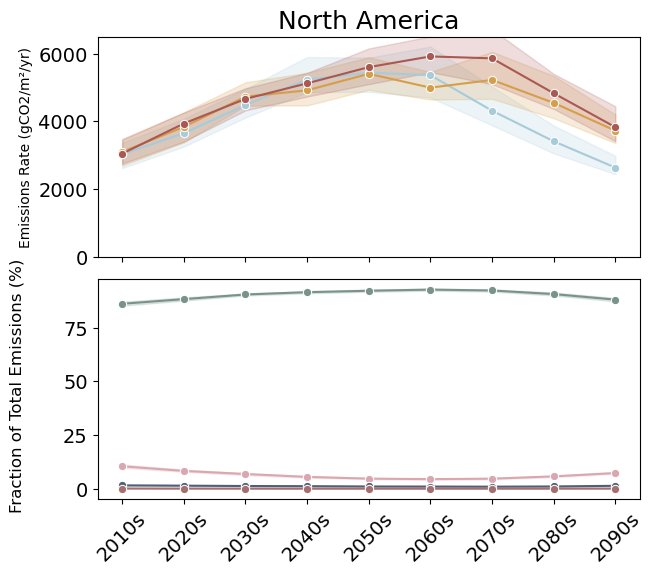

In [63]:
plot_figures_for_EAP('North America',6500)

C:\Users\zilin wang\AppData\Local\Temp\ipykernel_17208\475405766.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


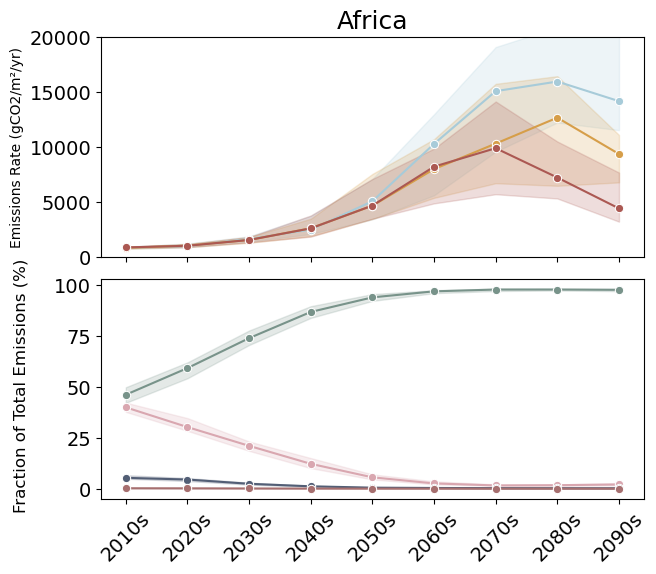

In [93]:
plot_figures_for_EAP('Africa',20000)

C:\Users\zilin wang\AppData\Local\Temp\ipykernel_17208\475405766.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


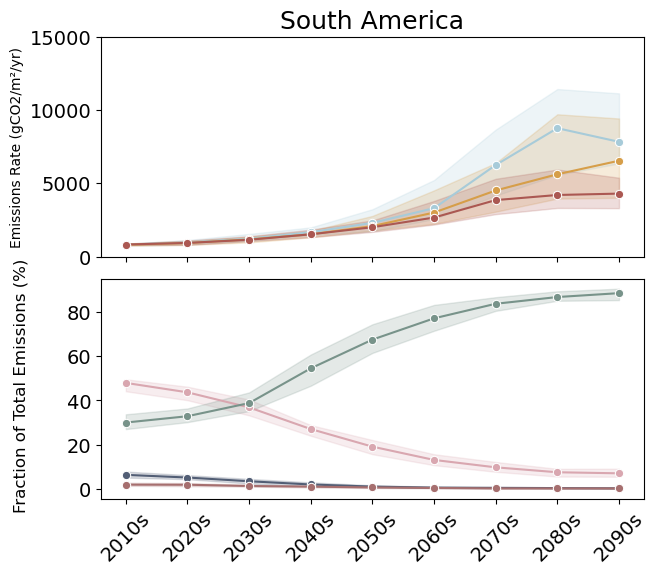

In [87]:
plot_figures_for_EAP('South America',15000)

C:\Users\zilin wang\AppData\Local\Temp\ipykernel_17208\1793975355.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


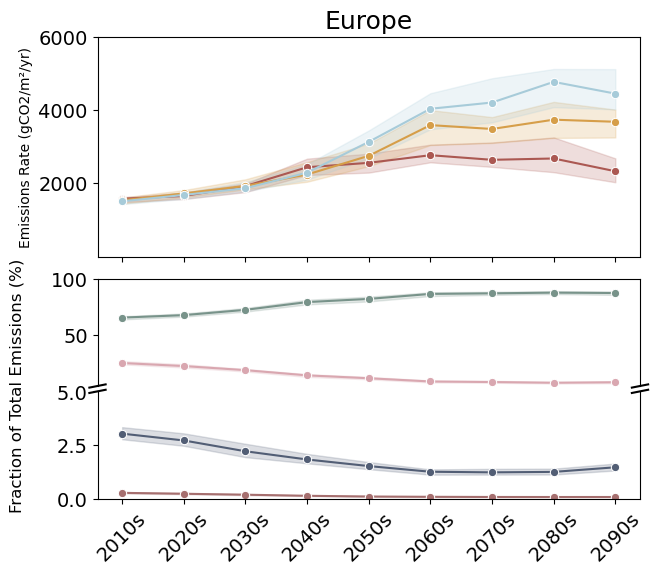

In [79]:
plot_figures_for_main_region('Europe',5,5)

C:\Users\zilin wang\AppData\Local\Temp\ipykernel_17208\1793975355.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


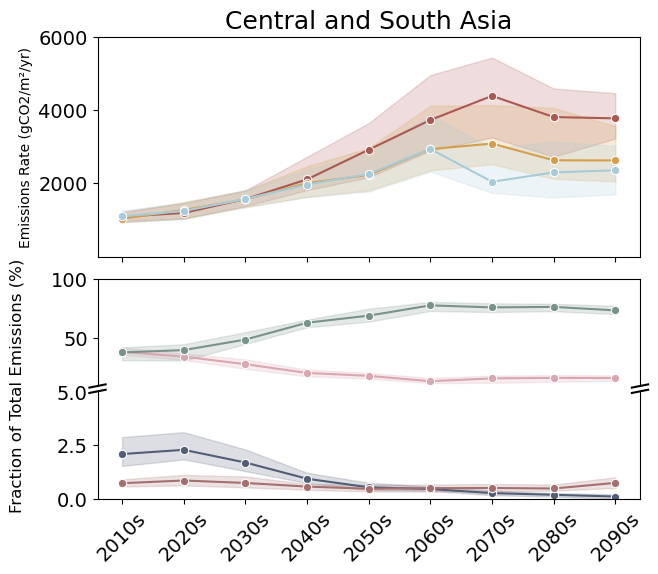

In [80]:
plot_figures_for_main_region('Central and South Asia',10,5)

In [83]:
def plot_figures_for_EAP(main_region, ax1_ylimit):
   # Filter the data for the given main_region.
    df_region = df[df['Main_regi'] == main_region]
    df_long_region = df_long[df_long['Main_regi'] == main_region]
    
    # Create a figure with two main sections:
    # 1. Reservoir Emissions Rate Trend plot (top)
    # 2. Broken y-axis plot for the decadal trend (bottom)
    fig = plt.figure(figsize=(7, 6))
    # Reduced vertical spacing between Plot 1 and Plot 2 (hspace=0.1)
    outer = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.1)
    
    # ----- Plot 1: Reservoir Emissions Rate Trend by SSP -----
    ax1 = fig.add_subplot(outer[0])
    ssp_palette = ['#a7cbd9', '#d69e49', '#ab5852']
    pathway_colors = ['#d9a7b0','#525e75','#78938a','#a66f6f']
    #ab5852 #d69e49 #a7cbd9
    sns.lineplot(
        data=df_region, 
        x='decade', 
        y='total_emissions_ghg_rate_gco2_m_2_yr', 
        hue='ssp', 
        marker='o',
        estimator=np.median,
        palette=ssp_palette,
        ax=ax1
    )
    # Hide x-axis label and tick labels since x-axis is shared with Plot 2.
    ax1.xaxis.label.set_visible(False)
    ax1.set_ylim(0, ax1_ylimit)
    ax1.tick_params(axis='x', labelbottom=False)
    ax1.set_ylabel("Emissions Rate (gCO2/m²/yr)")
    ax1.set_title(f"{main_region}",fontsize =18)
    ax1.grid(False)
    
    # Enlarge tick label sizes and legend text for Plot 1.
    ax1.tick_params(axis='both', which='major', labelsize=14)
    if ax1.get_legend() is not None:
        ax1.get_legend().remove()
    # ----- Plot 2: Broken y-axis Plot for Decadal Trend -----
    ax2 = fig.add_subplot(outer[1])
    sns.lineplot(
        data=df_long_region,
        x='decade',
        y='fraction',
        hue='pathway',
        marker='o',
        estimator=np.median,
        palette=pathway_colors,
        ax=ax2
    )
    # Hide x-axis label and tick labels since x-axis is shared with Plot 2.
    ax2.xaxis.label.set_visible(False)
    ax2.tick_params(axis='x', labelbottom=True)
    ax2.set_ylabel("")
    if ax2.get_legend() is not None:
        ax2.get_legend().remove()
    # Enlarge tick label sizes and legend text for Plot 1.
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    for tick in ax2.get_xticklabels():
        tick.set_rotation(45)
    fig.text(
    0, 0.3,                          # x, y in figure coords (0–1)
    "Fraction of Total Emissions (%)",      # the label
    va='center',                        # vertical alignment
    rotation='vertical', 
    fontsize=12
    )
    
    plt.tight_layout()
    plt.savefig(f'Figure/{main_region}_grand.svg', dpi=300, bbox_inches='tight')

C:\Users\zilin wang\AppData\Local\Temp\ipykernel_17208\475405766.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


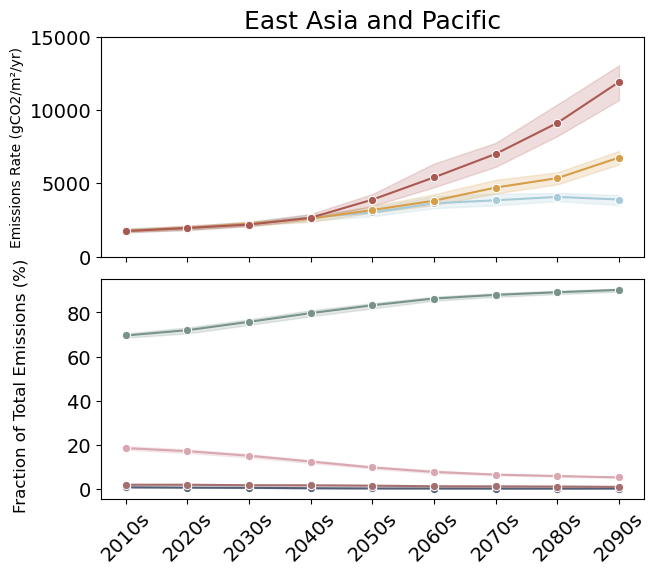

In [85]:
plot_figures_for_EAP('East Asia and Pacific',15000)